# TP : Descente de Gradient "From Scratch"

## 1. Cadre Mathématique

Nous cherchons à ajuster les paramètres $a$ et $b$ d'un modèle linéaire $f(x) = ax + b$ pour minimiser l'erreur quadratique moyenne (**MSE**) définie par :

$$J(a, b) = \frac{1}{2m} \sum_{i=1}^{m} (ax^{(i)} + b - y^{(i)})^2$$

Pour minimiser $J$, nous calculons le gradient, c'est-à-dire les dérivées partielles par rapport à chaque paramètre :

$$\frac{\partial J(a, b)}{\partial a} = \frac{1}{m} \sum_{i=1}^{m} x^{(i)}(ax^{(i)} + b - y^{(i)})$$

$$\frac{\partial J(a, b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (ax^{(i)} + b - y^{(i)})$$

La règle de mise à jour des poids lors de la descente de gradient, avec un taux d'apprentissage $\alpha$, est :

$$a \leftarrow a - \alpha \frac{\partial J(a, b)}{\partial a}$$
$$b \leftarrow b - \alpha \frac{\partial J(a, b)}{\partial b}$$

---

## Références

Les ressources utilisées et citées dans ce document :

1. Les fonctions convexes — Bibmath : https://www.bibmath.net/ressources/index.php?action=affiche&quoi=mathspe/cours/convexe.html
2. Convexity tutorial — M. J. Osborne (cours et tutoriel) : https://mjo.osborne.economics.utoronto.ca/index.php/tutorial/index/1/cv1/t

Les mentions "(voir [1])" et "(voir [1], [2])" dans les sections ci-dessus renvoient respectivement à ces références.

# Exercices du projet gradient

Ce notebook contient les réponses aux questions de la fiche sur le gradient et la convexité.


## 1 : Gradient de l'erreur quadratique (régression linéaire)

Pour un modèle linéaire $f(x)=wx+b$ et un jeu de données $(x_i,y_i)_{i=1\ldots N}$, l'erreur quadratique moyenne est :
$$L(w,b)=\frac{1}{2N} \sum_{i=1}^N (wx_i+b-y_i)^2. $$

### (a) Dérivées partielles :
En différentiant par rapport à $w$ et $b$, on obtient :
$$\frac{\partial L}{\partial w}=\frac{1}{N} \sum_{i=1}^N (wx_i+b-y_i)x_i, \qquad \frac{\partial L}{\partial b}=\frac{1}{N} \sum_{i=1}^N (wx_i+b-y_i).$$

### (b) Démonstration des formules statistiques :

En posant $\nabla \mathcal{L}(w^*, b^*) = 0$, les dérivées partielles s'annulent, ce qui donne les deux équations normales suivantes :

1. $\sum_{i=1}^N (w^*x_i + b^* - y_i) = 0$
2. $\sum_{i=1}^N (w^*x_i + b^* - y_i)x_i = 0$

**1. Obtention de $b^*$ :**
À partir de la première équation :
$$w^* \sum_{i=1}^N x_i + \sum_{i=1}^N b^* - \sum_{i=1}^N y_i = 0$$
$$w^* \sum_{i=1}^N x_i + N*b^* - \sum_{i=1}^N y_i = 0$$
$$N*b^*  = \sum_{i=1}^N y_i - w^* \sum_{i=1}^N x_i $$
En divisant par $N$ et en utilisant les moyennes $\bar{x} = \frac{1}{N}\sum x_i$ et $\bar{y} = \frac{1}{N}\sum y_i$, nous obtenons :
$$ b^* = \bar{y} - w^* \bar{x}$$

**2. Obtention de $w^*$ :**
En remplaçant $b^*$ dans la seconde équation :
$$\sum_{i=1}^N (w^* x_i + (\bar{y} - w^* \bar{x}) - y_i)x_i = 0$$
$$\sum_{i=1}^N (w^* x_i - w^* \bar{x} + \bar{y} - y_i)x_i = 0$$
$$\sum_{i=1}^N (w^*(x_i - \bar{x}) - (y_i - \bar{y}))x_i = 0$$
On remplace $x_i$ par $(x_i - \bar{x}+\bar{x})$ et que la somme des écarts à la moyenne est nulle , ce qui donne :
$$\sum_{i=1}^N (w^*(x_i - \bar{x}) - (y_i - \bar{y}))(x_i - \bar{x}+\bar{x}) = 0$$
$$\sum_{i=1}^N (w^*(x_i - \bar{x})(x_i - \bar{x}) - (y_i - \bar{y}))(x_i - \bar{x}) + \sum_{i=1}^N (w^*(x_i - \bar{x})(\bar{x}) - (y_i - \bar{y}))(\bar{x}) = 0$$
$$\sum_{i=1}^N (w^*(x_i - \bar{x})(x_i - \bar{x}) - (y_i - \bar{y}))(x_i - \bar{x}) + \bar{x}*\sum_{i=1}^N (w^*(x_i - \bar{x}) - (y_i - \bar{y})) = 0$$
$$\sum_{i=1}^N \underbrace{(w^*(x_i - \bar{x})^2 - (y_i - \bar{y})(x_i - \bar{x}))}_{\text{C'est le terme principal}} + \bar{x} \sum_{i=1}^N \underbrace{(w^*(x_i - \bar{x}) - (y_i - \bar{y}))}_{= 0} = 0$$
$$w^* \sum_{i=1}^N (x_i - \bar{x})^2 - \sum_{i=1}^N (y_i - \bar{y})(x_i - \bar{x}) = 0$$

En isolant $w^*$, nous obtenons les formules statistiques classiques :
$$w^* = \frac{\sum_{i=1}^N (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^N (x_i - \bar{x})^2} = \frac{\text{Cov}(x, y)}{\text{Var}(x)}, \qquad b^* = \bar{y} - w^* \bar{x}$$


## 2. Calcul complet et optimisation analytique

Soit $f(x,y)=x^2 e^y - 3xy^2$.

### (a) Gradient :
$$\frac{\partial f}{\partial x}=2x e^y - 3y^2, \qquad \frac{\partial f}{\partial y}=x^2 e^y - 6xy.$$

Donc : $\nabla f(x,y)=\bigl(2x e^y - 3y^2,\; x^2 e^y - 6xy\bigr).$

### (b) Hessienne :
Les dérivées secondes sont :
$$\frac{\partial^2 f}{\partial x^2} = 2 e^y, \qquad \frac{\partial^2 f}{\partial x \partial y} = 2x e^y - 6y = \frac{\partial^2 f}{\partial y \partial x} (Formule-Taylor), \qquad \frac{\partial^2 f}{\partial y^2} = x^2 e^y - 6x.$$

La matrice Hessienne est donc :
$$\nabla^2 f(x,y)=\begin{pmatrix}2 e^y & 2x e^y - 6y \\ 2x e^y - 6y & x^2 e^y - 6x\end{pmatrix}. $$

### (c) Évaluation au point $A=(1,0)$ :
Le gradient en $A$ est :
$$\nabla f(1,0) = (2\cdot 1 \cdot e^0 - 3\cdot 0^2,\; 1^2 e^0 - 6\cdot 1 \cdot 0) = (2,1).$$
La Hessienne en $A$ est :
$$\nabla^2 f(1,0)=\begin{pmatrix}2 & 2 \\ 2 & -5\end{pmatrix}. $$

La direction où la fonction décroît le plus vite est l'opposée du gradient :
$$-\nabla f(1,0)=(-2,-1).$$
On peut également donner la direction unitaire $(-2/\sqrt{5},-1/\sqrt{5})$.


## 3. Distance, gradient et convexité

Soit $g(x)=\|x-a\|^2$ pour un $a\in\mathbb{R}^n$ fixé.

### (a) Montrer que $\nabla g(x)=2(x-a)$ :
En développant la norme, $g(x) = \sum_{i=1}^n (x_i-a_i)^2$.
Pour chaque composante, $\frac{\partial g}{\partial x_i}=2(x_i-a_i)$.
Ainsi $\nabla g(x)=2(x-a)$.

### (b) Point critique unique :
Le gradient s'annule si et seulement si $2(x-a)=0$, donc $x=a$.
Il existe donc un unique point critique, $x=a$.

### (c) Hessienne et nature du point critique :

Soit la fonction $g(x) = \|x - a\|^2$. En développant le produit scalaire (carré de la norme) :
$$g(x) = \|x - a\|^2= (x - a)^\top (x - a) = x^\top x - 2a^\top x + a^\top a$$

*   **Le gradient :** $\nabla g(x) = 2x - 2a = 2(x - a)$.
*   **La Hessienne :** La Hessienne est la dérivée du gradient par rapport à $x$.
    $$\nabla^2 g(x) = \frac{\partial}{\partial x} [2x - 2a] = 2I_n$$
    où $I_n$ est la matrice identité de taille $n \times n$. Cette matrice est **constante** (elle ne dépend pas de $x$).

Une matrice symétrique $M$ est dite **définie positive** si, pour tout vecteur non nul $v \in \mathbb{R}^n$, on a $v^\top M v > 0$.

Appliquons cela à notre matrice $M = 2I_n$ :
$$v^\top (2I_n) v = 2 \cdot (v^\top I_n v) = 2 \cdot (v^\top v) = 2 \|v\|^2$$

Comme la norme au carré d'un vecteur non nul est strictement positive ($\|v\|^2 > 0$), alors $2\|v\|^2 > 0$. 
**Conclusion :** La matrice $2I_n$ est définie positive. 

> *Alternative :* Les valeurs propres de $2I_n$ sont toutes égales à 2. Comme toutes les valeurs propres sont strictement positives, la matrice est définie positive.
---
Pour conclure sur la convexité et l'optimalité, nous utilisons les deux résultats de votre cours :

#### A. Caractérisation de la convexité (Théorème 1.3)
> "Si $\nabla^2 f(x)$ est définie positive pour tout $x$, alors $f$ est strictement convexe."

*   **Application :** Comme nous avons démontré que $\nabla^2 g(x) = 2I_n$ est définie positive, le **Théorème 1.3** implique directement que la fonction $g(x) = \|x - a\|^2$ est **strictement convexe** sur $\mathbb{R}^n$. (voir [1])

#### B. Optimalité globale sous convexité (Propriété 1.4)
> "Si $f$ est convexe et différentiable, alors tout point critique de $f$ est un minimum global."

*   **Application :** 
    1. Nous savons que $g$ est strictement convexe (donc convexe).
    2. Le point critique est défini par $\nabla g(x) = 0 \iff 2(x - a) = 0 \iff x = a$.
    3. D'après la **Propriété 1.4**, puisque le point $x=a$ est un point critique et que la fonction est convexe, ce point est nécessairement le **minimum global**. (voir [1], [2])


## 4. Les limites du critère de la Hessienne

La fonction $h(x) = x^4$ est une fonction de classe $C^\infty$. Pour démontrer sa stricte convexité, le moyen le plus efficace consiste à étudier sa dérivée seconde.

**1. Calcul des dérivées :**
*   $h'(x) = 4x^3$
*   $h''(x) = 12x^2$

**2. Étude du signe de la dérivée seconde :**
*   Pour tout $x \in \mathbb{R}$, $x^2 \ge 0$, donc $12x^2 \ge 0$.
*   La dérivée seconde est nulle uniquement en $x = 0$.
*   Comme $h''(x) > 0$ pour tout $x \neq 0$, la fonction $h$ est **strictement convexe** sur $\mathbb{R}$. (voir [1])

---

### Vérification par l'inégalité de Jensen (Lien avec la définition)

On va utiliser le fait que pour une fonction strictement convexe, le segment reliant deux points $(x, f(x))$ et $(y, f(y))$ se situe strictement au-dessus de la courbe.

Posons $$\phi(t) = t h(x) + (1-t) h(y) - h(tx + (1-t)y).$$

Nous voulons montrer que $\phi(t) > 0$ pour $t \in [0, 1]$ et $x \neq y$.

1.  **Aux bornes :**
    *   Si $t=0$, $\phi(0) = h(y) - h(y) = 0$.
    *   Si $t=1$, $\phi(1) = h(x) - h(x) = 0$.

2.  **Étude de la dérivée de $\phi(t)$ :**
    $$\phi'(t) = h(x) - h(y) - h'(tx + (1-t)y) \cdot (x - y)$$
    $$\phi''(t) = -h''(tx + (1-t)y) \cdot (x - y)^2$$

3.  **Analyse du signe de $\phi''(t)$ :**
    *   Puisque $h''(x) = 12x^2$, nous avons $h''(z) \ge 0$ pour tout $z$.
    *   Donc $\phi''(t) = -12(tx + (1-t)y)^2 \cdot (x - y)^2$.
    *   Comme $(x-y)^2 > 0$ (car $x \neq y$), alors $\phi''(t) \le 0$. 

La fonction $\phi(t)$ est donc **concave**. Comme elle est concave et s'annule en $t=0$ et $t=1$, elle est strictement positive sur l'intervalle ouvert $]0, 1[$.

**Conclusion :**
Puisque $\phi(t) > 0$ pour tout $t \in [0, 1]$, alors :
$$t h(x) + (1-t) h(y) > h(tx + (1-t)y)$$
Ce qui démontre bien que $h(x) = x^4$ est **strictement convexe**. (voir [1])

Conclusion : la stricte convexité n'implique pas que la dérivée seconde soit strictement positive partout.
Autrement dit, la réciproque du critère de la Hessienne est fausse : $h''(x)\ge 0$ est nécessaire pour la convexité, mais $h''(x)>0$ n'est pas nécessaire partout pour qu'une fonction soit strictement convexe. (voir [1], [2])


## Partie II : Travaux pratiques sous Python (NumPy, SymPy, Matplotlib)

### 5. Vérification symbolique avec SymPy

On vérifie avec SymPy le gradient et la Hessienne de la fonction $f(x,y)=x^2 e^y - 3 x y^2$.


In [1]:
import sympy as sp

x, y = sp.symbols("x y")
f = x**2 * sp.exp(y) - 3 * x * y**2
grad_f = [sp.diff(f, var) for var in (x, y)]
hess_f = sp.hessian(f, (x, y))

print(f"le gradient de f est : {grad_f}")
print(f"la hessienne de f est : {hess_f}")

# Affichage propre
print("--- Gradient de f ---")
sp.pprint(grad_f)

print("\n--- Hessienne de f ---")
sp.pprint(hess_f)


le gradient de f est : [2*x*exp(y) - 3*y**2, x**2*exp(y) - 6*x*y]
la hessienne de f est : Matrix([[2*exp(y), 2*x*exp(y) - 6*y], [2*x*exp(y) - 6*y, x**2*exp(y) - 6*x]])
--- Gradient de f ---
⎡     y      2   2  y        ⎤
⎣2⋅x⋅ℯ  - 3⋅y , x ⋅ℯ  - 6⋅x⋅y⎦

--- Hessienne de f ---
⎡       y           y      ⎤
⎢    2⋅ℯ       2⋅x⋅ℯ  - 6⋅y⎥
⎢                          ⎥
⎢     y         2  y       ⎥
⎣2⋅x⋅ℯ  - 6⋅y  x ⋅ℯ  - 6⋅x ⎦


### 6. Génération de données "Jouets" avec NumPy

On génère 100 points $x$ uniformes dans $[0,10]$ et $y=3x+2+\varepsilon$ avec $\varepsilon\sim\mathcal{N}(0,1)$.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.random.uniform(0, 10, 100)
epsilon = np.random.randn(100)
y = 3 * X + 2 + epsilon

# Utiliser le helper de tracé
# plot_training(X=X, y=y, kind="reg")


### 7. Implémentation de la Descente de Gradient

Dans la partie 1, nous avons défini la fonction de coût (**MSE** - Mean Squared Error) pour un modèle linéaire $f(x) = wx + b$ :

$$L(w, b) = \frac{1}{2N} \sum_{i=1}^N (w x_i + b - y_i)^2$$

où $N$ est le nombre d'échantillons.

Les dérivées partielles (gradients) s'obtiennent en dérivant $L$ par rapport à $w$ et $b$ :

$$\frac{\partial L}{\partial w} = \frac{1}{N} \sum_{i=1}^N (w x_i + b - y_i) x_i \quad , \quad \frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N (w x_i + b - y_i)$$

*Remarque : nous choisissons la constante $1/(2N)$ dans la définition de $L$ pour que les gradients n'aient pas de facteur $1/2$ devant (simplification des calculs).*

#### Mise en correspondance avec le code Python
Nous implémentons trois fonctions principales :

*   **`compute_loss(w, b, X, y)`** : Calcule $L(w, b)$ et retourne un scalaire (la valeur de la perte).
*   **`compute_gradients(w, b, X, y)`** : Calcule et retourne le couple $(\frac{\partial L}{\partial w}, \frac{\partial L}{\partial b})$.
*   **`gradient_descent(X, y, w_init, b_init, alpha, epochs)`** : Boucle d'entraînement qui met à jour les paramètres $w$ et $b$ selon les règles suivantes :

$$w \leftarrow w - \alpha \frac{\partial L}{\partial w} \quad , \quad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

où $\alpha$ représente le pas d'apprentissage (*learning rate*).

**Exemple d'appel :**
```python
w_star, b_star, losses, trajectory = gradient_descent(X, y, 0.0, 0.0, 0.01, 100)
```

**Interprétation :**
*   **`losses`** : Liste contenant l'évolution de la valeur de la fonction de coût $L$ à chaque époque.
*   **`trajectory`** : Liste stockant les couples $(w_k, b_k)$ à chaque itération pour permettre de tracer la trajectoire d'optimisation dans l'espace des paramètres.

In [3]:
def compute_loss(w, b, X, y):
    # L(w,b) = 1/(2N) * sum_i (w*x_i + b - y_i)^2
    N = len(X)
    y_pred = w * X + b
    return np.mean((y_pred - y) ** 2) / 2

def compute_gradients(w, b, X, y):
    # dw = (1/N) * sum_i (y_pred_i - y_i) * x_i
    # db = (1/N) * sum_i (y_pred_i - y_i)
    y_pred = w * X + b
    dw = np.mean((y_pred - y) * X)
    db = np.mean(y_pred - y)
    return dw, db

def gradient_descent(X, y, w_init, b_init, alpha, epochs):
    w, b = w_init, b_init
    losses = []
    trajectory = [(w, b)]
    for _ in range(epochs):
        dw, db = compute_gradients(w, b, X, y)
        w -= alpha * dw
        b -= alpha * db
        losses.append(compute_loss(w, b, X, y))
        trajectory.append((w, b))
    return w, b, losses, np.array(trajectory)

def plot_training(losses=None, trajectory=None, X=None, y=None,
                  w_star=None, b_star=None, W=None, B=None, Z=None,
                  trajectory_other=None, kind='all', logy=False):
    """Utility plotting function that adapts to provided data:
    - kind 'loss' : plots loss curve (requires losses)
    - kind 'reg'  : plots data scatter and regression line (requires X,y and w_star,b_star)
    - kind 'contour' : plots contour of Z(W,B) and overlays trajectory (requires W,B,Z and trajectory)
    - kind 'all' : attempts to draw all available plots (stacked)
    Returns nothing, shows matplotlib figures."""
    import matplotlib.pyplot as plt
    import numpy as _np
    # Loss plot
    if kind in ('loss', 'all') and losses is not None:
        plt.figure(figsize=(7,4))
        plt.plot(range(1, len(losses)+1), losses, marker='o')
        plt.xlabel('Époque')
        plt.ylabel('Loss')
        if logy:
            plt.yscale('log')
        plt.title('Courbe de perte')
        plt.grid(True)
        plt.show()
    # Regression plot (data + fitted line)
    if kind in ('reg', 'all') and X is not None and y is not None and w_star is not None and b_star is not None:
        plt.figure(figsize=(7,5))
        plt.scatter(X, y, alpha=0.6, edgecolor='k', label='Données')
        x_line = _np.linspace(min(X), max(X), 200)
        y_line = w_star * x_line + b_star
        plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Droite: y={w_star:.3f}x+{b_star:.3f}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Données et droite de régression')
        plt.legend()
        plt.grid(True)
        plt.show()
    # Contour + trajectory plot
    if kind in ('contour', 'all') and W is not None and B is not None and Z is not None and trajectory is not None:
        plt.figure(figsize=(7,6))
        cs = plt.contour(W, B, Z, levels=30, cmap='viridis')
        plt.clabel(cs, inline=True, fontsize=8)
        traj = _np.array(trajectory)
        plt.plot(traj[:,0], traj[:,1], marker='o', color='red', label='Trajectoire')
        if trajectory_other is not None:
            tro = _np.array(trajectory_other)
            plt.plot(tro[:,0], tro[:,1], marker='x', color='orange', label='Trajectoire (autre)')
        plt.xlabel('w')
        plt.ylabel('b')
        plt.title('Lignes de niveau et trajectoire')
        plt.legend()
        plt.grid(True)
        plt.show()

# End of helper


### Exercice 8 : Visualisation de l’apprentissage (courbe de perte)

On exécute l'algorithme avec $w_{init}=0$, $b_{init}=0$, $\alpha=0.01$ et 100 époques, puis on trace la perte et la droite de régression.


w* = 3.1983, b* = 0.9064


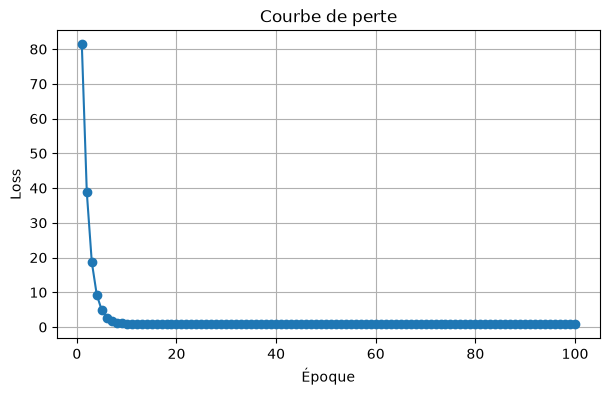

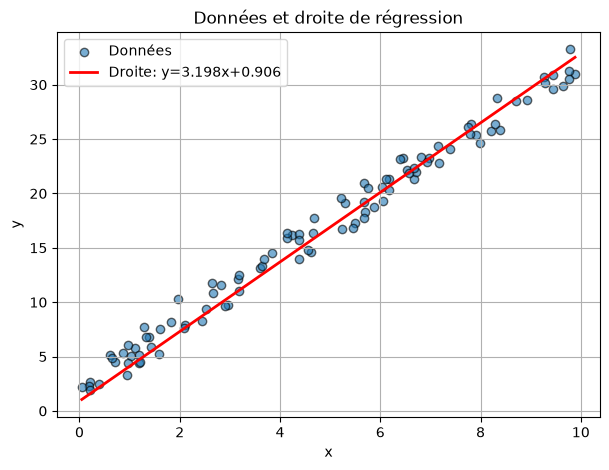

In [4]:
w_init, b_init = 0.0, 0.0
alpha = 0.01
epochs = 100

w_star, b_star, losses, trajectory = gradient_descent(X, y, w_init, b_init, alpha, epochs)

print(f"w* = {w_star:.4f}, b* = {b_star:.4f}")

# Tracer la courbe de perte via le helper
plot_training(losses=losses, kind="loss")

# Tracer la droite de régression estimée via le helper
plot_training(X=X, y=y, w_star=w_star, b_star=b_star, kind="reg")


### Exercice 9 : Exploration de la surface de coût et divergence

On trace les lignes de niveau de $L(w,b)$ et on superpose la trajectoire $(w_k,b_k)$.
On relance ensuite l'entraînement avec un pas trop grand $\alpha=0.5$ pour observer la divergence.


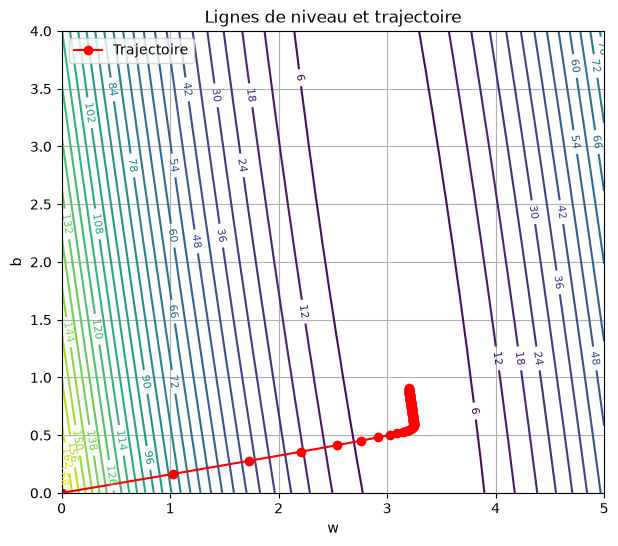

Pas trop grand alpha = 0.5: w = -1760831841698903311173497167343592244439076593715729377847205611834052759732752883539397038978070782650426810945241088.0000, b = -273847791041977802232635571203572183555617065755875636000935703151068948923348082058236674426048855024923465320759296.0000


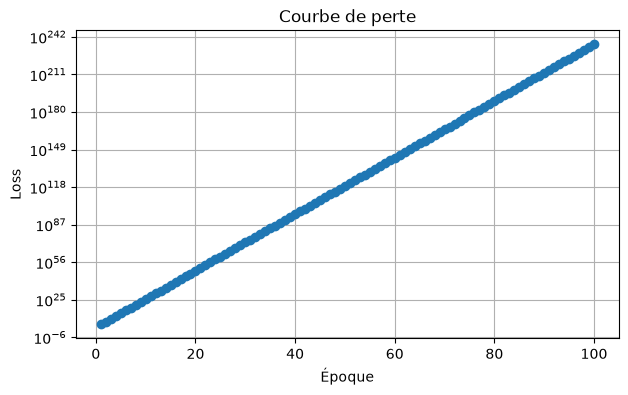

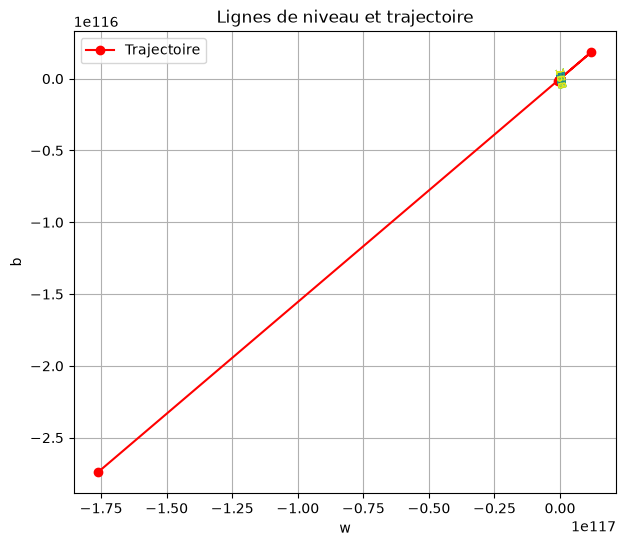

In [ ]:
w_values = np.linspace(0, 5, 80)
b_values = np.linspace(0, 4, 80)
W, B = np.meshgrid(w_values, b_values)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = compute_loss(W[i, j], B[i, j], X, y)
        
# L_vals = np.array([compute_loss(w, b, X, y) for w in w_values for b in b_values]).reshape(W.shape)

# _,_,_,history = gradient_descent(X, y, 0, 0, 0.01, 100)

# Tracer les lignes de niveau + trajectoire via le helper
plot_training(W=W, B=B, Z=Z, trajectory=trajectory, kind="contour")

alpha_crash = 0.5
w_crash, b_crash, losses_crash, trajectory_crash = gradient_descent(X, y, w_init, b_init, alpha_crash, epochs)
print(f"Pas trop grand alpha = {alpha_crash}: w = {w_crash:.4f}, b = {b_crash:.4f}")

# Tracer la courbe de perte divergente (échelle log si souhaitée)
plot_training(losses=losses_crash, kind="loss", logy=True)

# Tracer la trajectoire avec alpha élevé
plot_training(W=W, B=B, Z=Z, trajectory=trajectory_crash, kind="contour")
